# ComexStat (MDIC) - Comércio Exterior Brasileiro

Dados mensais de exportação e importação por capítulo SH2, detalhamento por produto SH4, e exportações de minérios por país de destino.

**Capítulos analisados:**
- Cap. 26: Minérios, escórias e cinzas (ferro, manganês, cobre, bauxita, nióbio, etc.)
- Cap. 72: Ferro fundido, ferro e aço
- Cap. 27: Combustíveis minerais
- Cap. 84: Máquinas e equipamentos mecânicos

**Fonte:** MDIC - ComexStat (bulk CSV, balanca.economia.gov.br)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import json, os

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

DATA_DIR = '../data/comexstat'
CUTOFF = '2015-01-01'

SH4_LABELS = {
    '2601': 'Minério de ferro',
    '2602': 'Manganês',
    '2603': 'Cobre',
    '2604': 'Níquel',
    '2605': 'Cobalto',
    '2606': 'Alumínio/Bauxita',
    '2607': 'Chumbo',
    '2608': 'Zinco',
    '2609': 'Estanho',
    '2610': 'Cromo',
    '2611': 'Tungstênio',
    '2613': 'Molibdênio',
    '2614': 'Titânio',
    '2615': 'Nióbio/Tântalo/Vanádio',
    '2616': 'Metais preciosos',
    '2617': 'Outros minérios',
    '2620': 'Escórias e cinzas',
    '2621': 'Outras escórias',
}

In [2]:
# Load all three datasets
totals = pd.read_csv(os.path.join(DATA_DIR, 'monthly_totals.csv'), index_col=0, parse_dates=True)
sh4 = pd.read_csv(os.path.join(DATA_DIR, 'monthly_by_sh4.csv'), index_col=0, parse_dates=True)
by_country = pd.read_csv(os.path.join(DATA_DIR, 'export_ores_by_country.csv'), index_col=0, parse_dates=True)

totals = totals[totals.index >= CUTOFF]
sh4 = sh4[sh4.index >= CUTOFF]
by_country = by_country[by_country.index >= CUTOFF]

# Convert FOB to US$ millions, kg to million tonnes
for df in [totals, sh4, by_country]:
    for c in df.columns:
        if 'fob' in c:
            df[c] = df[c] / 1e6
        elif '_kg' in c:
            df[c] = df[c] / 1e9  # to million tonnes

print(f'Totals:     {totals.shape} | {totals.index.min().date()} to {totals.index.max().date()}')
print(f'SH4 detail: {sh4.shape} | {sh4.index.min().date()} to {sh4.index.max().date()}')
print(f'By country: {by_country.shape} | {by_country.index.min().date()} to {by_country.index.max().date()}')

Totals:     (134, 16) | 2015-01-01 to 2026-02-01
SH4 detail: (134, 610) | 2015-01-01 to 2026-02-01
By country: (134, 15) | 2015-01-01 to 2026-02-01


## Exportações e Importações por Capítulo SH2 (FOB)

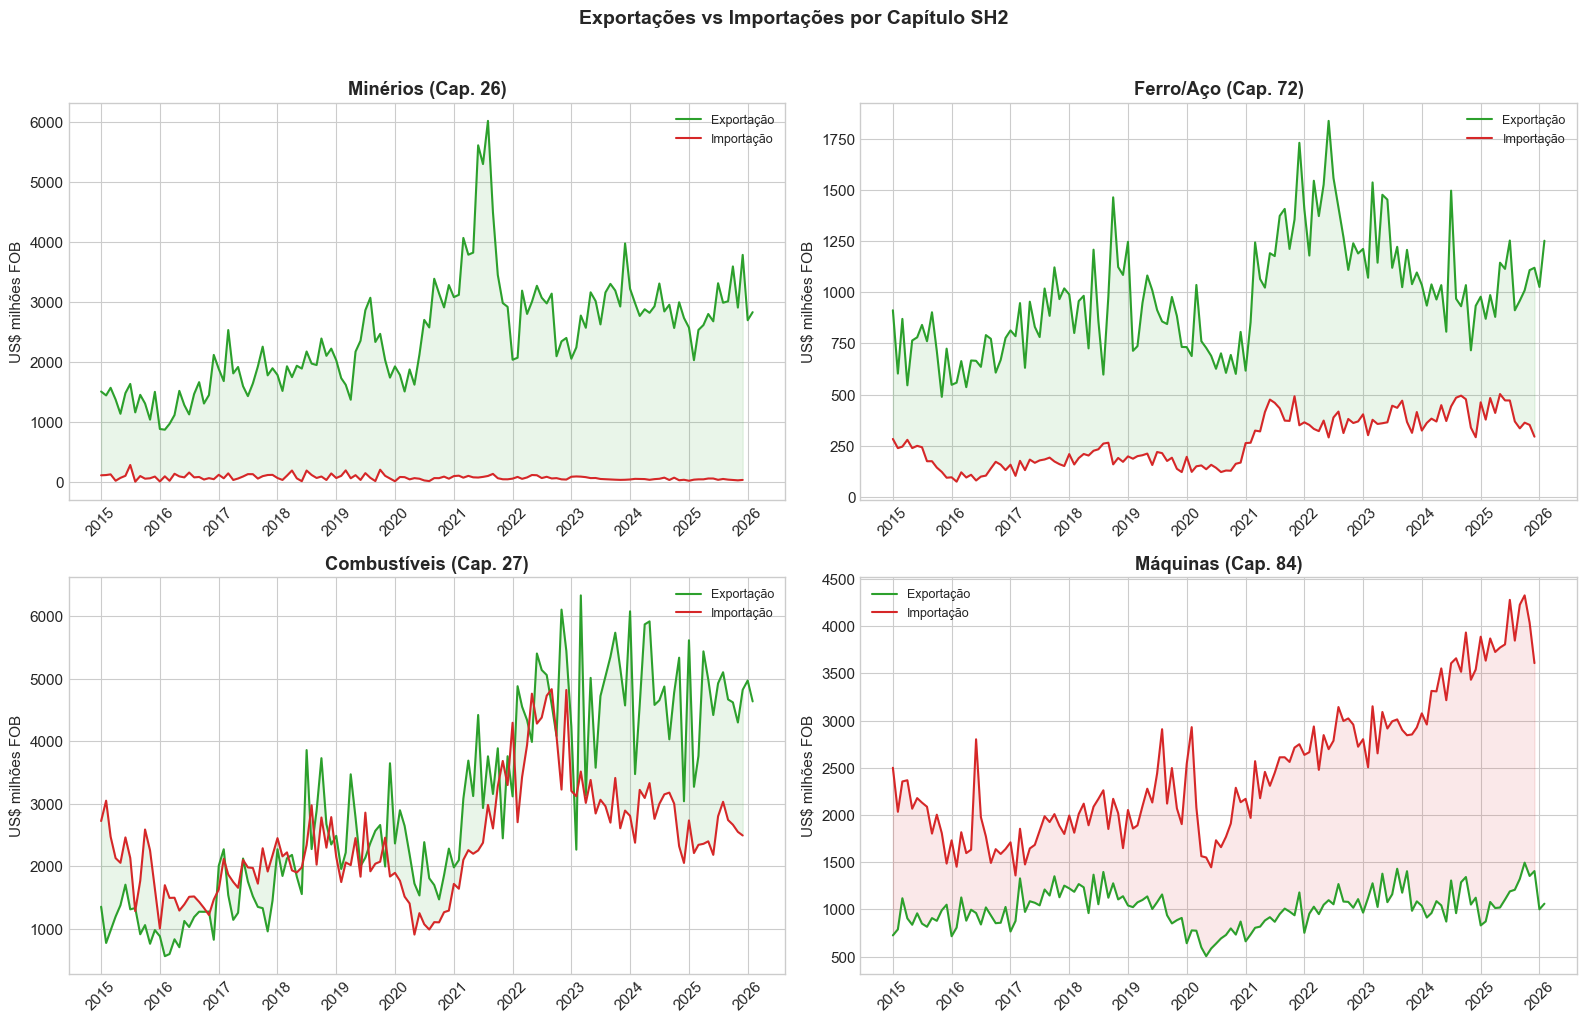

In [3]:
chapters = [
    ('26', 'Minérios (Cap. 26)', '#1f77b4'),
    ('72', 'Ferro/Aço (Cap. 72)', '#ff7f0e'),
    ('27', 'Combustíveis (Cap. 27)', '#2ca02c'),
    ('84', 'Máquinas (Cap. 84)', '#d62728'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (ch, label, color) in zip(axes.flat, chapters):
    exp_col = f'export_{ch}_fob_usd'
    imp_col = f'import_{ch}_fob_usd'
    ax.plot(totals.index, totals[exp_col], label='Exportação', color='#2ca02c', linewidth=1.5)
    ax.plot(totals.index, totals[imp_col], label='Importação', color='#d62728', linewidth=1.5)
    ax.fill_between(totals.index, totals[exp_col], totals[imp_col], alpha=0.1,
                    color='#2ca02c' if totals[exp_col].mean() > totals[imp_col].mean() else '#d62728')
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('US$ milhões FOB')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Exportações vs Importações por Capítulo SH2', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Saldo Comercial por Capítulo (FOB)

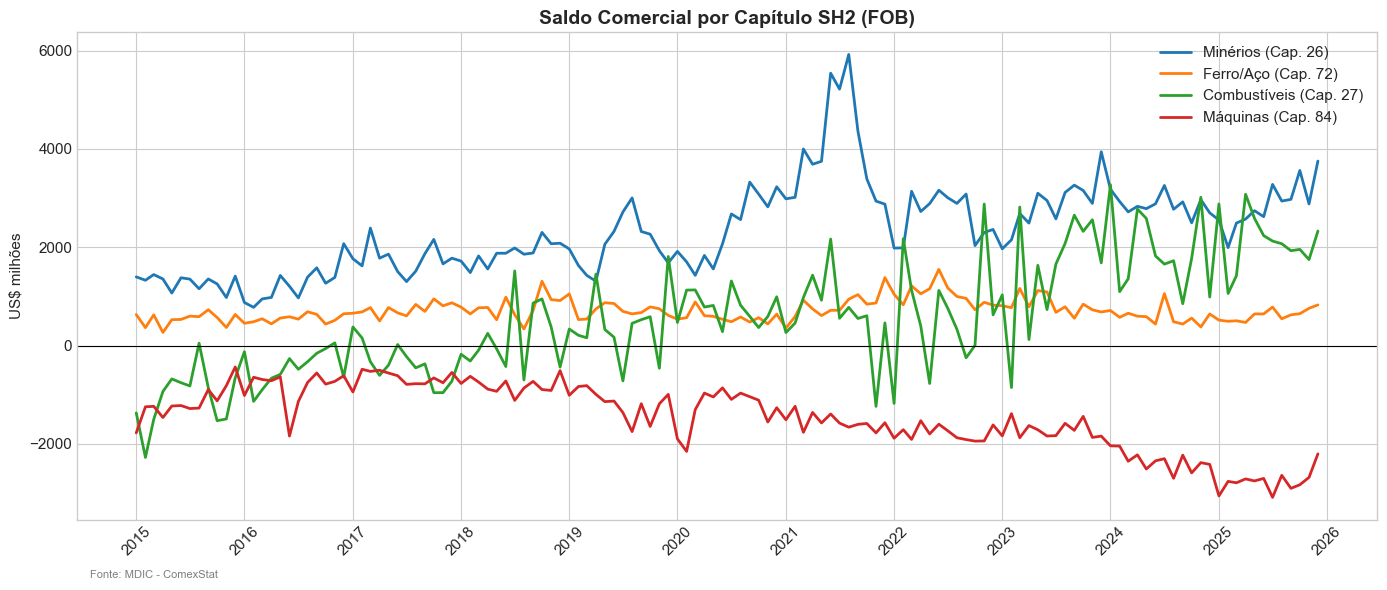

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))

for ch, label, color in chapters:
    balance = totals[f'export_{ch}_fob_usd'] - totals[f'import_{ch}_fob_usd']
    ax.plot(totals.index, balance, label=label, color=color, linewidth=2)

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Saldo Comercial por Capítulo SH2 (FOB)', fontsize=14, fontweight='bold')
ax.set_ylabel('US$ milhões')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)
ax.annotate('Fonte: MDIC - ComexStat', xy=(0.01, -0.12), xycoords='axes fraction', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

## Exportações de Minérios por Produto SH4 (Cap. 26)
Detalhamento por tipo de minério: ferro (2601), manganês (2602), cobre (2603), bauxita (2606), nióbio (2615), etc.

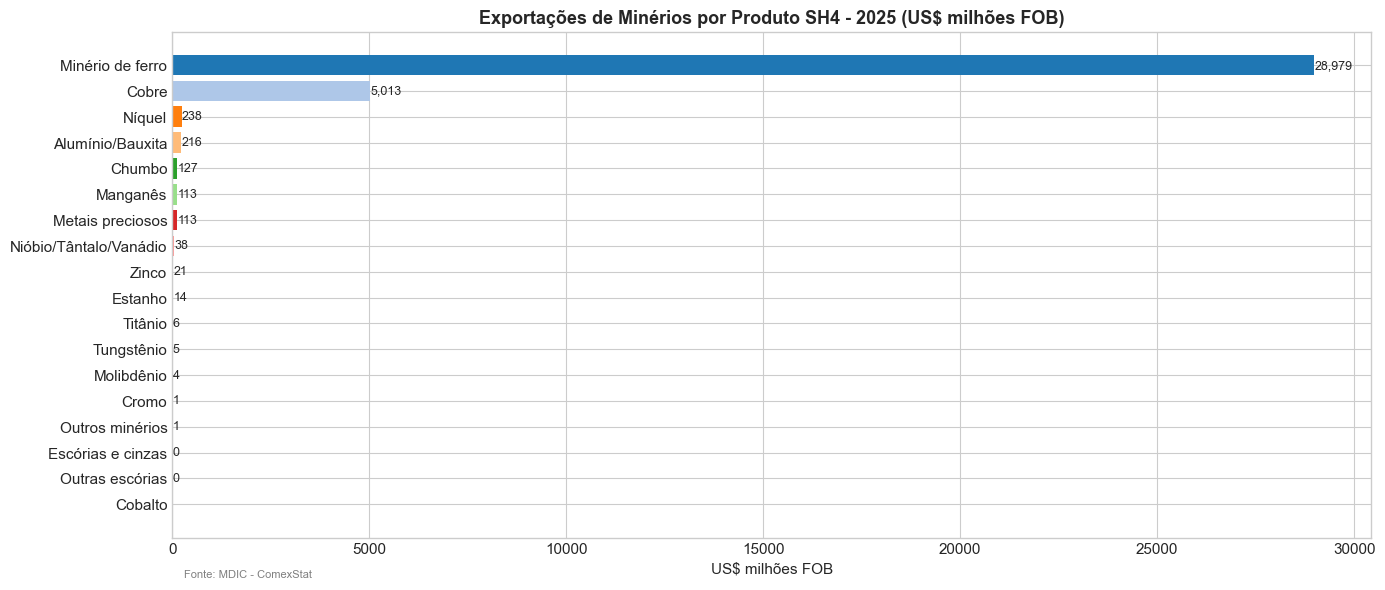

In [5]:
# Top ore exports by SH4 (annual totals, last full year)
sh4_exp_fob = {code: f'export_{code}_fob_usd' for code in SH4_LABELS if f'export_{code}_fob_usd' in sh4.columns}

annual = sh4[[c for c in sh4_exp_fob.values()]].resample('YE').sum()
last_year = annual.iloc[-2] if len(annual) > 1 else annual.iloc[-1]  # last full year
last_year = last_year.sort_values(ascending=False)

# Bar chart of top products
fig, ax = plt.subplots(figsize=(14, 6))
labels = [SH4_LABELS.get(c.replace('export_', '').replace('_fob_usd', ''), c) for c in last_year.index]
colors = plt.cm.tab20(range(len(labels)))
bars = ax.barh(labels[::-1], last_year.values[::-1], color=colors[::-1])

for bar, val in zip(bars, last_year.values[::-1]):
    if val > 0:
        ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, f'{val:,.0f}', va='center', fontsize=9)

ax.set_title(f'Exportações de Minérios por Produto SH4 - {last_year.name.year} (US$ milhões FOB)', fontsize=13, fontweight='bold')
ax.set_xlabel('US$ milhões FOB')
ax.annotate('Fonte: MDIC - ComexStat', xy=(0.01, -0.08), xycoords='axes fraction', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

## Evolução Mensal - Minério de Ferro (2601) vs Outros Minérios

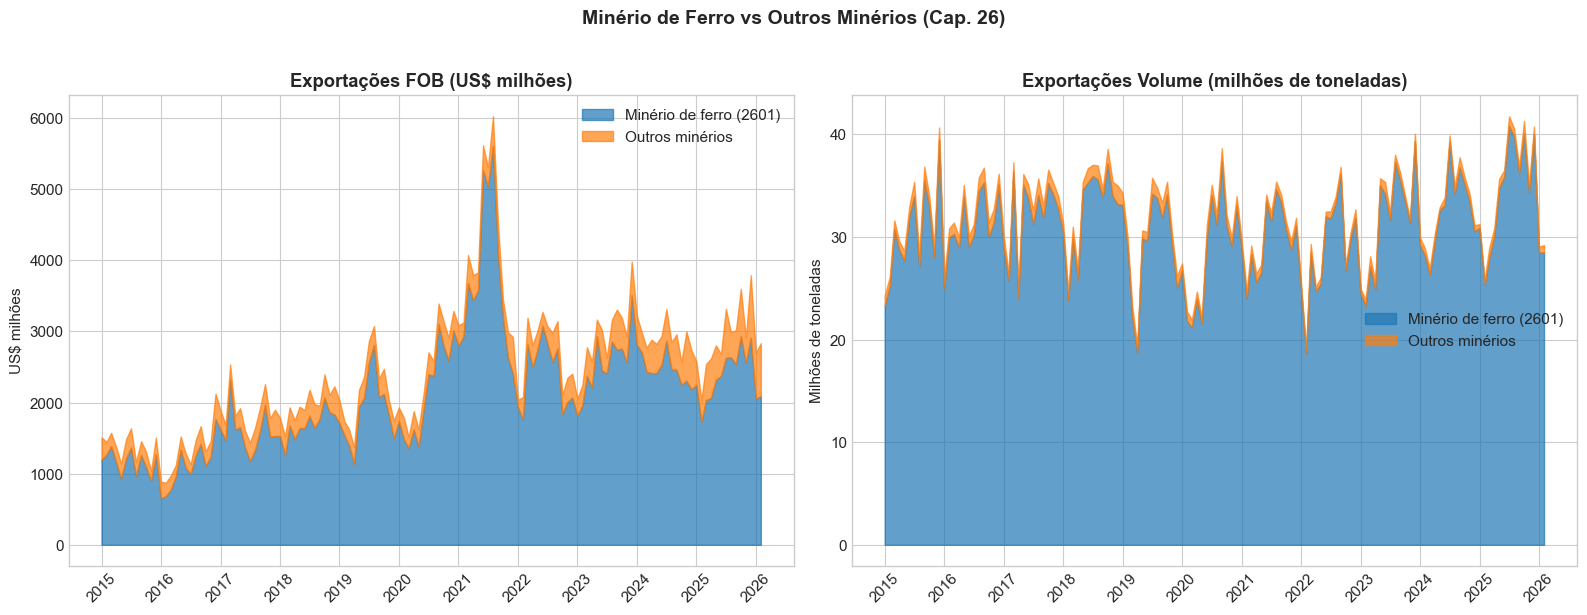

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# FOB
ax = axes[0]
iron_fob = sh4.get('export_2601_fob_usd', pd.Series(dtype=float))
others_fob = sh4[[c for c in sh4.columns if c.startswith('export_26') and 'fob' in c and c != 'export_2601_fob_usd']].sum(axis=1)
ax.fill_between(sh4.index, iron_fob, label='Minério de ferro (2601)', color='#1f77b4', alpha=0.7)
ax.fill_between(sh4.index, iron_fob, iron_fob + others_fob, label='Outros minérios', color='#ff7f0e', alpha=0.7)
ax.set_title('Exportações FOB (US$ milhões)', fontweight='bold')
ax.set_ylabel('US$ milhões')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.tick_params(axis='x', rotation=45)

# Volume (kg)
ax = axes[1]
iron_kg = sh4.get('export_2601_kg', pd.Series(dtype=float))
others_kg = sh4[[c for c in sh4.columns if c.startswith('export_26') and '_kg' in c and c != 'export_2601_kg']].sum(axis=1)
ax.fill_between(sh4.index, iron_kg, label='Minério de ferro (2601)', color='#1f77b4', alpha=0.7)
ax.fill_between(sh4.index, iron_kg, iron_kg + others_kg, label='Outros minérios', color='#ff7f0e', alpha=0.7)
ax.set_title('Exportações Volume (milhões de toneladas)', fontweight='bold')
ax.set_ylabel('Milhões de toneladas')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.tick_params(axis='x', rotation=45)

fig.suptitle('Minério de Ferro vs Outros Minérios (Cap. 26)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Exportações de Minérios (Cap. 26) por País de Destino
Top 15 países importadores de minérios brasileiros (FOB).

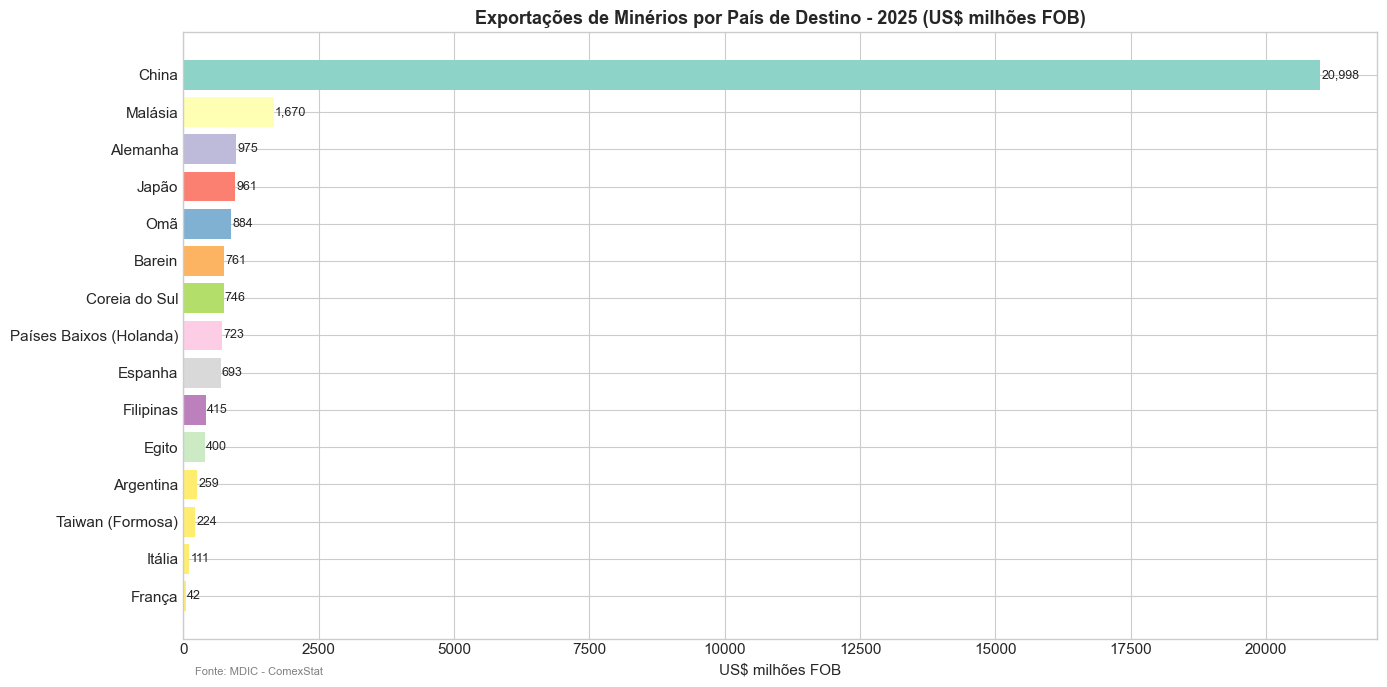

In [7]:
# Annual totals by country (last full year)
annual_country = by_country.resample('YE').sum()
last = annual_country.iloc[-2] if len(annual_country) > 1 else annual_country.iloc[-1]
last = last.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
labels = [c.replace('exp_26_', '').replace('_fob', '') for c in last.index]
colors = plt.cm.Set3(range(len(labels)))
bars = ax.barh(labels[::-1], last.values[::-1], color=colors[::-1])

for bar, val in zip(bars, last.values[::-1]):
    if val > 0:
        ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2, f'{val:,.0f}', va='center', fontsize=9)

ax.set_title(f'Exportações de Minérios por País de Destino - {last.name.year} (US$ milhões FOB)', fontsize=13, fontweight='bold')
ax.set_xlabel('US$ milhões FOB')
ax.annotate('Fonte: MDIC - ComexStat', xy=(0.01, -0.06), xycoords='axes fraction', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

## Evolução Mensal - Exportações de Minérios por Destino
Evolução temporal dos principais destinos (China, Japão, Coreia do Sul, etc.).

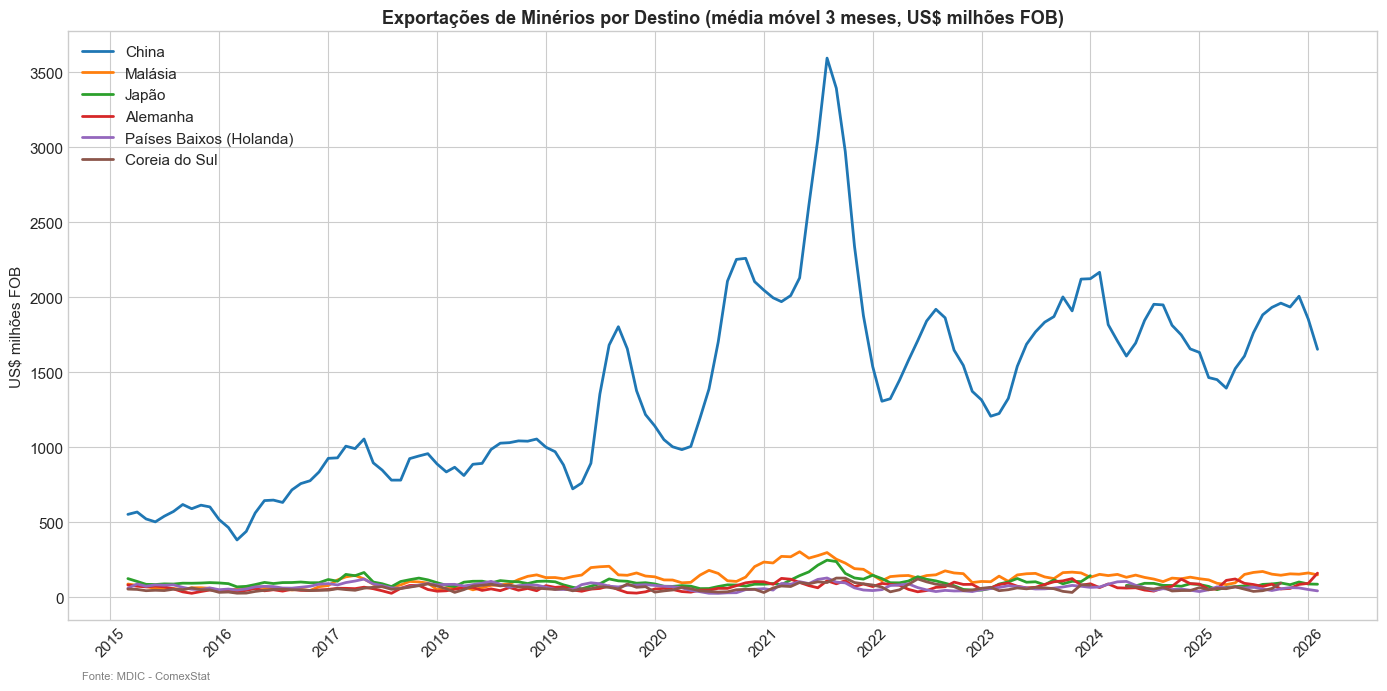

In [8]:
fig, ax = plt.subplots(figsize=(14, 7))

# Top 6 countries by total FOB
top6 = by_country.sum().nlargest(6)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for (col, _), color in zip(top6.items(), colors):
    label = col.replace('exp_26_', '').replace('_fob', '')
    # 3-month rolling average for readability
    ax.plot(by_country.index, by_country[col].rolling(3).mean(), label=label, color=color, linewidth=2)

ax.set_title('Exportações de Minérios por Destino (média móvel 3 meses, US$ milhões FOB)', fontsize=13, fontweight='bold')
ax.set_ylabel('US$ milhões FOB')
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)
ax.annotate('Fonte: MDIC - ComexStat', xy=(0.01, -0.10), xycoords='axes fraction', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

## Composição das Exportações FOB por Capítulo

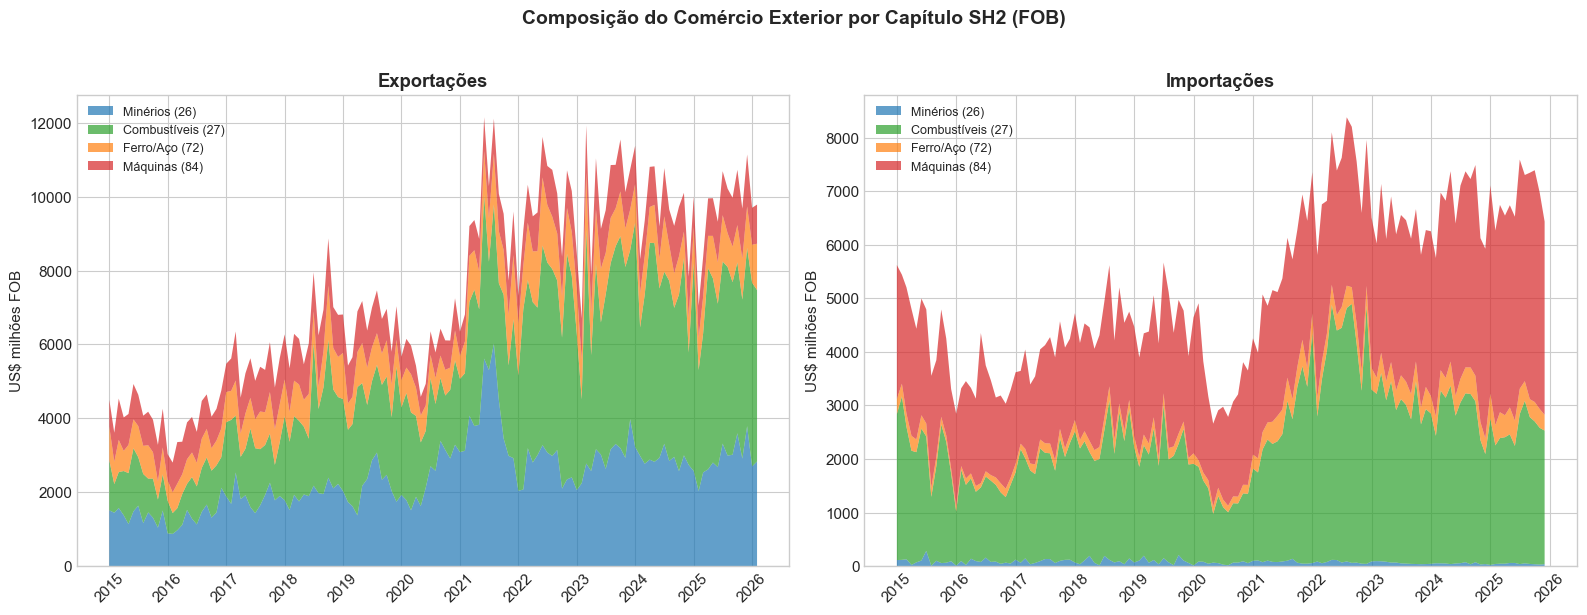

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

exp_data = pd.DataFrame({
    'Minérios (26)': totals['export_26_fob_usd'],
    'Combustíveis (27)': totals['export_27_fob_usd'],
    'Ferro/Aço (72)': totals['export_72_fob_usd'],
    'Máquinas (84)': totals['export_84_fob_usd'],
}, index=totals.index)

imp_data = pd.DataFrame({
    'Minérios (26)': totals['import_26_fob_usd'],
    'Combustíveis (27)': totals['import_27_fob_usd'],
    'Ferro/Aço (72)': totals['import_72_fob_usd'],
    'Máquinas (84)': totals['import_84_fob_usd'],
}, index=totals.index)

colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']

ax = axes[0]
ax.stackplot(exp_data.index, exp_data.T, labels=exp_data.columns, colors=colors, alpha=0.7)
ax.set_title('Exportações', fontweight='bold')
ax.set_ylabel('US$ milhões FOB')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.tick_params(axis='x', rotation=45)

ax = axes[1]
ax.stackplot(imp_data.index, imp_data.T, labels=imp_data.columns, colors=colors, alpha=0.7)
ax.set_title('Importações', fontweight='bold')
ax.set_ylabel('US$ milhões FOB')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.tick_params(axis='x', rotation=45)

fig.suptitle('Composição do Comércio Exterior por Capítulo SH2 (FOB)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Preço Implícito do Minério de Ferro (FOB/ton)
Razão entre o valor FOB e o peso exportado — proxy do preço médio de exportação.

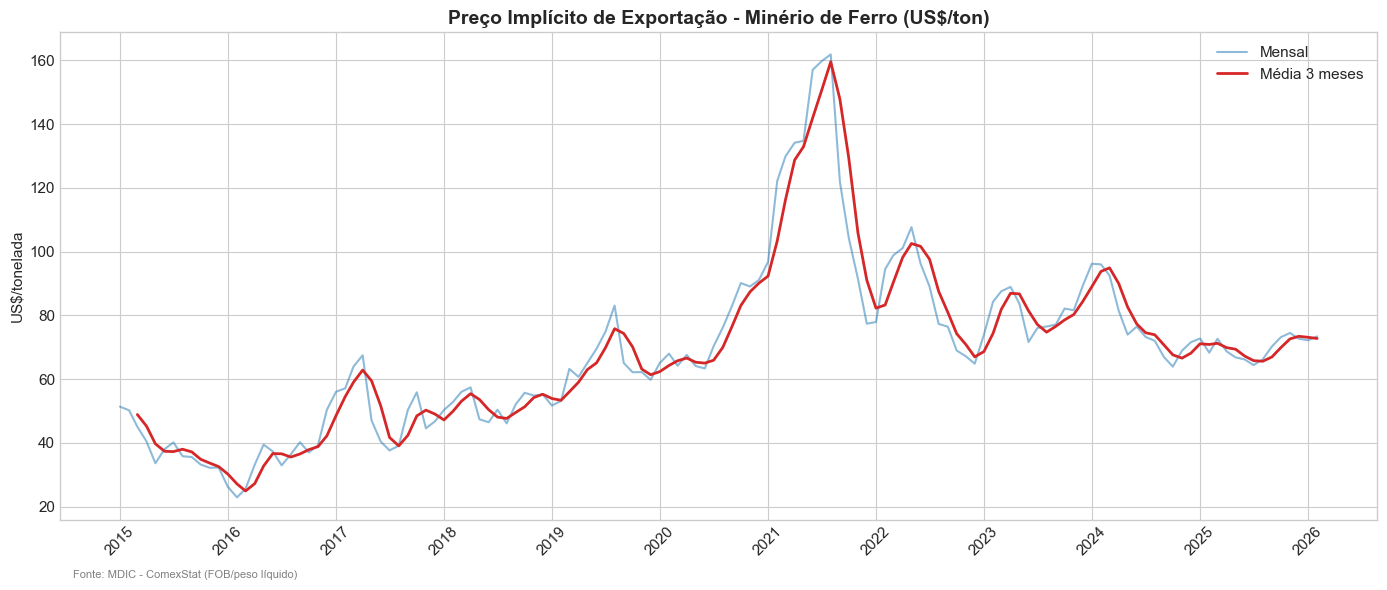

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))

# After loading: FOB is in US$ millions, kg is in million tonnes
# Price = (FOB_millions * 1e6) / (kg_million_tonnes * 1e9) = FOB_millions / (kg_million_tonnes * 1000)
# Simpler: reload raw columns to avoid unit confusion
_sh4_raw = pd.read_csv(os.path.join(DATA_DIR, 'monthly_by_sh4.csv'), index_col=0, parse_dates=True)
_sh4_raw = _sh4_raw[_sh4_raw.index >= CUTOFF]

iron_fob_raw = _sh4_raw['export_2601_fob_usd']
iron_kg_raw = _sh4_raw['export_2601_kg']
price = (iron_fob_raw / iron_kg_raw) * 1000  # (US$ / kg) * 1000 = US$ / tonne

price = price[(price > 10) & (price < 300)]

ax.plot(price.index, price, color='#1f77b4', linewidth=1.5, alpha=0.5, label='Mensal')
ax.plot(price.index, price.rolling(3).mean(), color='#d62728', linewidth=2, label='Média 3 meses')

ax.set_title('Preço Implícito de Exportação - Minério de Ferro (US$/ton)', fontsize=14, fontweight='bold')
ax.set_ylabel('US$/tonelada')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)
ax.annotate('Fonte: MDIC - ComexStat (FOB/peso líquido)', xy=(0.01, -0.12), xycoords='axes fraction', fontsize=8, color='gray')
plt.tight_layout()
plt.show()